# 📊 Analyse exploratoire — Stock et ventes sur produits frais

**Objectif** : comprendre les dynamiques de stock, de demande et de pertes sur des
références à courte durée de vie (DLC), afin d'identifier les SKU à risque et de
préparer la phase de modélisation prédictive.

**Données** : jeu de données simulé représentant 8 références (yaourts à boire,
fromages frais, desserts lactés) sur une année complète, avec saisonnalité
(Ramadan, été, fêtes) et incidents logistiques aléatoires.

> 💡 **Pour comprendre l'enjeu** : sur des produits frais, la gestion de stock est un
> arbitrage permanent entre deux risques opposés. Trop de stock → des produits
> périment avant d'être vendus (perte sèche). Pas assez de stock → rupture, client
> insatisfait, vente perdue. Ce notebook explore les données pour quantifier ces
> deux risques avant de construire un outil de prévision.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Chargement des données

Chaque ligne du jeu de données correspond à **une référence, un jour donné**, avec :
- la **demande** (ce que les clients ont commandé)
- la **production** (ce qui a été fabriqué)
- le **stock en fin de journée**
- les **pertes DLC** (produits jetés car périmés)
- un indicateur de **rupture** (stock insuffisant pour répondre à la demande)

In [2]:
df = pd.read_csv('../data/stock_ventes_simules.csv', parse_dates=['date'])
produits = pd.read_csv('../data/referentiel_produits.csv')

print(f"Période : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de SKU : {df['sku'].nunique()}")
df.head()


Période : 2025-01-01 -> 2025-12-30
Nombre de lignes : 2,912
Nombre de SKU : 8


,date,sku,produit,famille,dlc_jours,demande,production,stock_fin_journee,stock_securite,perte_dlc,rupture
0,2025-01-01,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,352,385,2314,612,162,False
1,2025-01-02,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,1968,2138,2387,612,97,False
2,2025-01-03,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,594,581,2286,612,88,False
3,2025-01-04,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,306,309,2197,612,92,False
4,2025-01-05,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,2468,2355,2084,612,0,False


**Référentiel produits** — la colonne `dlc_jours` est centrale : c'est le nombre
de jours pendant lesquels le produit reste vendable après fabrication. Plus ce
chiffre est bas, plus la gestion de stock doit être fine.

In [3]:
produits

,sku,nom,famille,dlc_jours,demande_base
0,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,850
1,YAB-002,Yaourt à boire fraise 1L,Yaourt à boire,18,620
2,YAB-003,Yaourt à boire pêche 1L,Yaourt à boire,18,410
3,FRF-001,Fromage frais nature 500g,Fromage frais,21,530
4,FRF-002,Fromage frais ail & fines herbes,Fromage frais,21,280
5,DES-001,Crème dessert vanille pack x4,Dessert lacté,14,460
6,DES-002,Crème dessert chocolat pack x4,Dessert lacté,14,590
7,DES-003,Flan caramel pack x4,Dessert lacté,12,310


## 2. Vue d'ensemble : demande et production

On commence par regarder l'évolution agrégée sur l'année, toutes références
confondues, pour repérer les grandes tendances et les pics saisonniers.

> 💡 **Pourquoi comparer demande et production ?** Si la production suit fidèlement
> la demande, le risque de sur-stock ou de rupture reste limité. Si les deux courbes
> divergent (production trop élevée ou trop faible par rapport à la demande), c'est
> souvent le signe d'un problème de planification — l'un des sujets centraux d'un
> processus S&OP (Sales & Operations Planning).

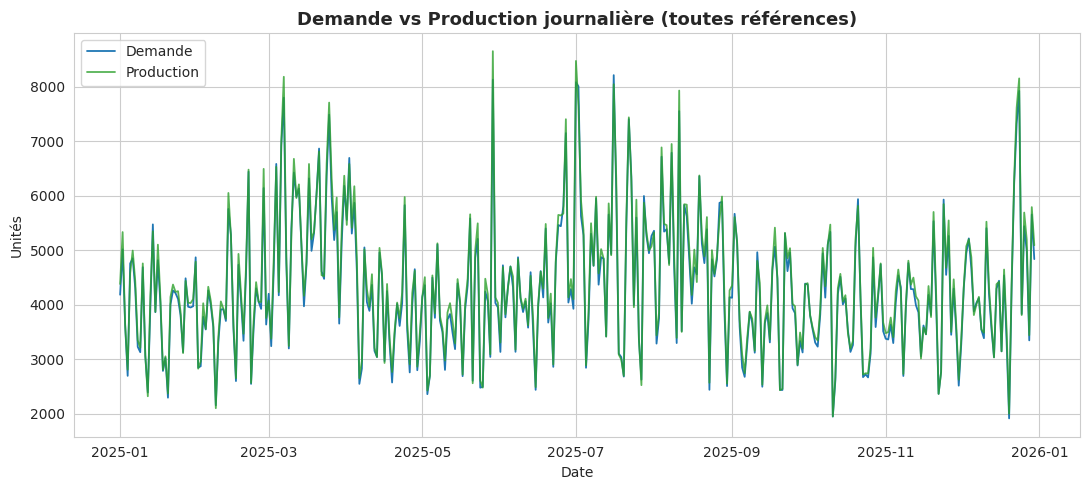

In [4]:
df_jour = df.groupby('date', as_index=False)[['demande', 'production', 'perte_dlc']].sum()

fig, ax = plt.subplots()
ax.plot(df_jour['date'], df_jour['demande'], label='Demande', color='#1f77b4', linewidth=1.3)
ax.plot(df_jour['date'], df_jour['production'], label='Production', color='#2ca02c', linewidth=1.3, alpha=0.8)
ax.set_title("Demande vs Production journalière (toutes références)")
ax.set_xlabel("Date")
ax.set_ylabel("Unités")
ax.legend()
plt.tight_layout()
plt.show()


On observe nettement trois pics de demande dans l'année : un pic important
autour de **mars-avril (Ramadan)**, un pic estival, et un pic plus court en fin
d'année (fêtes). Ces périodes sont critiques pour le dimensionnement du **stock
de sécurité** — la quantité de stock supplémentaire gardée en réserve pour
absorber les imprévus de demande sans tomber en rupture.

## 3. Analyse par famille de produits

On regroupe les 8 références en 3 familles (yaourts à boire, fromages frais,
desserts lactés) pour identifier si certaines catégories sont structurellement
plus à risque que d'autres.

In [5]:
df_famille = df.groupby('famille', as_index=False).agg(
    demande_totale=('demande', 'sum'),
    perte_dlc_totale=('perte_dlc', 'sum'),
    taux_rupture=('rupture', 'mean')
).sort_values('demande_totale', ascending=False)

df_famille['taux_rupture'] = (df_famille['taux_rupture'] * 100).round(2)
df_famille


,famille,demande_totale,perte_dlc_totale,taux_rupture
2,Yaourt à boire,724726,7323,4.12
0,Dessert lacté,519643,5051,5.22
1,Fromage frais,318751,1689,0.00


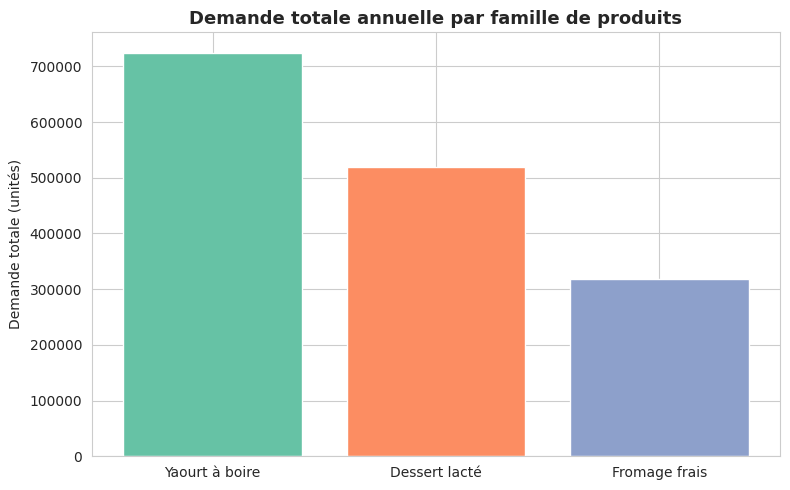

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set2', len(df_famille))
ax.bar(df_famille['famille'], df_famille['demande_totale'], color=colors)
ax.set_title("Demande totale annuelle par famille de produits")
ax.set_ylabel("Demande totale (unités)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 4. Pertes liées au dépassement de DLC

> 💡 **Qu'est-ce qu'une perte DLC ?** DLC signifie Date Limite de Consommation.
> Quand un produit reste trop longtemps en stock par rapport à sa DLC, il devient
> invendable et doit être détruit — c'est une perte sèche, à la fois financière et
> en termes de gaspillage. Sur les produits frais, c'est l'indicateur n°1 à
> surveiller, bien plus que sur des produits à longue conservation.

On identifie ici les références les plus exposées à ce risque.

In [7]:
df_sku = df.groupby(['sku', 'produit', 'famille', 'dlc_jours'], as_index=False).agg(
    demande_totale=('demande', 'sum'),
    perte_dlc_totale=('perte_dlc', 'sum'),
    taux_rupture=('rupture', 'mean')
)

df_sku['taux_perte_pct'] = (df_sku['perte_dlc_totale'] / df_sku['demande_totale'] * 100).round(2)
df_sku['taux_rupture_pct'] = (df_sku['taux_rupture'] * 100).round(2)
df_sku = df_sku.sort_values('taux_perte_pct', ascending=False)

df_sku[['sku', 'produit', 'dlc_jours', 'demande_totale', 'perte_dlc_totale', 'taux_perte_pct', 'taux_rupture_pct']]


,sku,produit,dlc_jours,demande_totale,perte_dlc_totale,taux_perte_pct,taux_rupture_pct
7,YAB-003,Yaourt à boire pêche 1L,18,163694,2551,1.56,0.00
0,DES-001,Crème dessert vanille pack x4,14,179631,2706,1.51,0.00
5,YAB-001,Yaourt à boire nature 1L,18,323348,3414,1.06,0.00
2,DES-003,Flan caramel pack x4,12,116810,851,0.73,9.89
1,DES-002,Crème dessert chocolat pack x4,14,223202,1494,0.67,5.77
3,FRF-001,Fromage frais nature 500g,21,210161,1293,0.62,0.00
6,YAB-002,Yaourt à boire fraise 1L,18,237684,1358,0.57,12.36
4,FRF-002,Fromage frais ail & fines herbes,21,108590,396,0.36,0.00


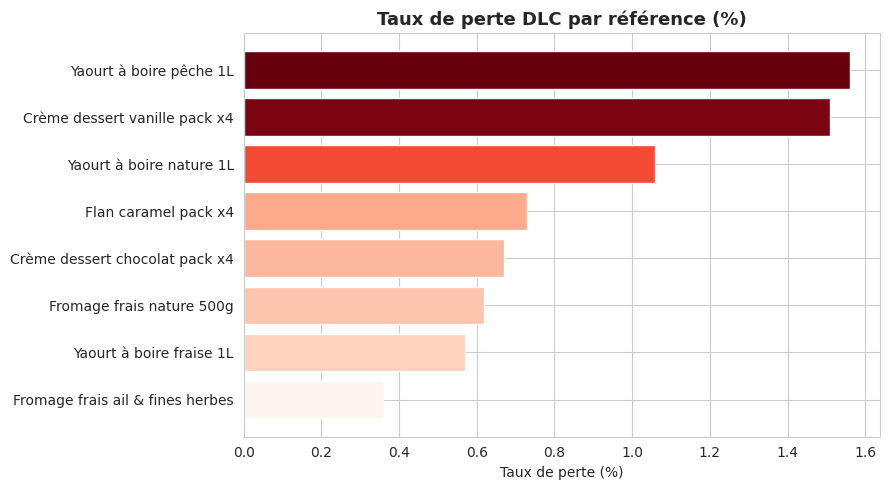

In [8]:
df_plot = df_sku.sort_values('taux_perte_pct')
fig, ax = plt.subplots(figsize=(9, 5))
norm = plt.Normalize(df_plot['taux_perte_pct'].min(), df_plot['taux_perte_pct'].max())
colors = plt.cm.Reds(norm(df_plot['taux_perte_pct']))
ax.barh(df_plot['produit'], df_plot['taux_perte_pct'], color=colors)
ax.set_title("Taux de perte DLC par référence (%)")
ax.set_xlabel("Taux de perte (%)")
plt.tight_layout()
plt.show()


**Lecture** : les références avec une DLC très courte (desserts lactés, 12-14
jours) sont structurellement plus exposées au risque de perte que les fromages
frais (DLC 21 jours) — ce qui confirme l'intuition métier et justifie un
traitement différencié du stock de sécurité par famille. Une référence à DLC
courte ne peut tout simplement pas se permettre le même niveau de stock tampon
qu'une référence à DLC plus longue.

## 5. Classification ABC/XYZ des références

> 💡 **Pour comprendre cette méthode** : c'est un outil classique de gestion de
> stock qui croise deux questions simples.
>
> **Première question — combien ça pèse ? (classement A/B/C)**
> On classe les références selon leur poids dans la demande totale : les
> références **A** sont celles qui, à elles seules, représentent 70% du volume
> vendu — ce sont les plus importantes à ne jamais perdre de vue. Les références
> **C** pèsent peu individuellement, même s'il y en a beaucoup. C'est le principe
> de Pareto ("20% des références font 80% du volume"), appliqué à la demande.
>
> **Deuxième question — est-ce que c'est prévisible ? (classement X/Y/Z)**
> On regarde si la demande d'une référence est stable d'un jour à l'autre
> (classe **X**, facile à prévoir) ou très irrégulière (classe **Z**, difficile à
> anticiper). Une référence avec une demande qui varie énormément demande plus de
> stock de sécurité, toutes choses égales par ailleurs.
>
> **En croisant les deux**, on obtient une carte de priorité : une référence
> classée **AZ** (gros volume + très imprévisible) est la plus critique à
> surveiller, car une erreur de prévision dessus a un impact fort ET difficile à
> anticiper. À l'inverse, une référence **CX** (petit volume + stable) peut être
> gérée avec des règles simples, sans y consacrer beaucoup d'attention.

In [9]:
# Classification ABC (Pareto sur la demande)
df_sku = df_sku.sort_values('demande_totale', ascending=False).reset_index(drop=True)
df_sku['cum_pct'] = df_sku['demande_totale'].cumsum() / df_sku['demande_totale'].sum() * 100

def classe_abc(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

df_sku['classe_abc'] = df_sku['cum_pct'].apply(classe_abc)

# Classification XYZ (coefficient de variation de la demande journalière)
# Le coefficient de variation = écart-type / moyenne. Plus il est élevé, plus la
# demande est irrégulière d'un jour à l'autre.
cv = df.groupby('sku')['demande'].agg(lambda x: x.std() / x.mean())
df_sku['cv_demande'] = df_sku['sku'].map(cv)

def classe_xyz(cv):
    if cv <= 0.25:
        return 'X'   # demande stable
    elif cv <= 0.45:
        return 'Y'   # demande modérément variable
    else:
        return 'Z'   # demande très irrégulière

df_sku['classe_xyz'] = df_sku['cv_demande'].apply(classe_xyz)
df_sku['classe_abc_xyz'] = df_sku['classe_abc'] + df_sku['classe_xyz']

df_sku[['sku', 'produit', 'demande_totale', 'classe_abc', 'cv_demande', 'classe_xyz', 'classe_abc_xyz']]


,sku,produit,demande_totale,classe_abc,cv_demande,classe_xyz,classe_abc_xyz
0,YAB-001,Yaourt à boire nature 1L,323348,A,0.694879,Z,AZ
1,YAB-002,Yaourt à boire fraise 1L,237684,A,0.412374,Y,AY
2,DES-002,Crème dessert chocolat pack x4,223202,A,0.578951,Z,AZ
3,FRF-001,Fromage frais nature 500g,210161,A,0.357799,Y,AY
4,DES-001,Crème dessert vanille pack x4,179631,B,0.512906,Z,BZ
5,YAB-003,Yaourt à boire pêche 1L,163694,B,0.431232,Y,BY
6,DES-003,Flan caramel pack x4,116810,C,0.597043,Z,CZ
7,FRF-002,Fromage frais ail & fines herbes,108590,C,0.399332,Y,CY


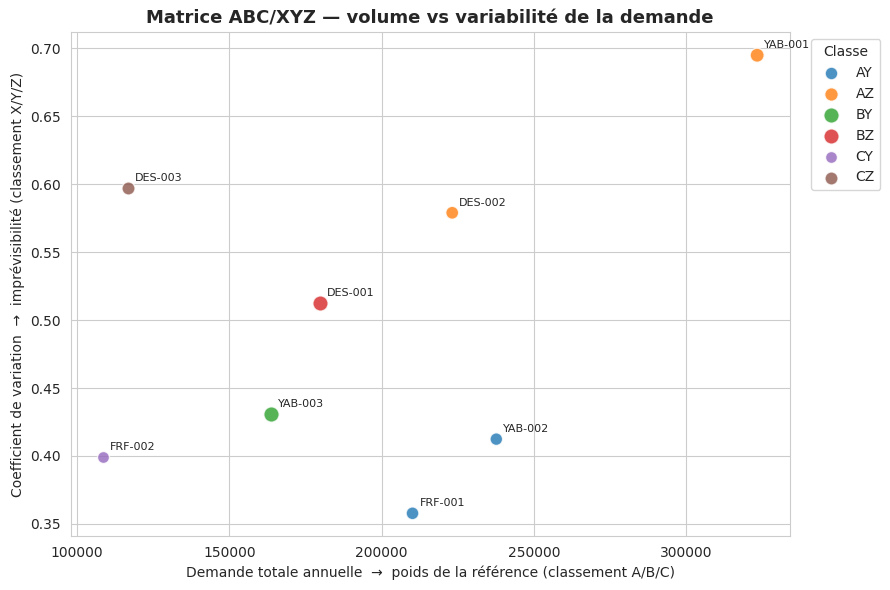

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
classes = df_sku['classe_abc_xyz'].unique()
palette = dict(zip(sorted(classes), sns.color_palette('tab10', len(classes))))

for classe, grp in df_sku.groupby('classe_abc_xyz'):
    ax.scatter(grp['demande_totale'], grp['cv_demande'],
               s=grp['taux_perte_pct']*40 + 60, label=classe,
               color=palette[classe], alpha=0.8, edgecolor='white')
    for _, row in grp.iterrows():
        ax.annotate(row['sku'], (row['demande_totale'], row['cv_demande']),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_title("Matrice ABC/XYZ — volume vs variabilité de la demande")
ax.set_xlabel("Demande totale annuelle  →  poids de la référence (classement A/B/C)")
ax.set_ylabel("Coefficient de variation  →  imprévisibilité (classement X/Y/Z)")
ax.legend(title='Classe', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
classes_critiques = df_sku[df_sku['classe_abc_xyz'].isin(['AZ', 'AY'])].sort_values('demande_totale', ascending=False)
noms_critiques = ', '.join(classes_critiques['produit'].tolist())
print("Références classées AZ ou AY (prioritaires) :")
print(noms_critiques)


Références classées AZ ou AY (prioritaires) :
Yaourt à boire nature 1L, Yaourt à boire fraise 1L, Crème dessert chocolat pack x4, Fromage frais nature 500g


**Lecture** : dans ce jeu de données, les références classées **AZ ou AY**
(volume élevé + variabilité forte à modérée) ressortent ci-dessus. Ce sont elles
qui doivent être prioritaires pour la mise en place d'un stock de sécurité
dynamique et d'une prévision de demande affinée — une erreur de prévision sur
ces références a un impact fort (gros volume) ET difficile à anticiper (forte
variabilité). À l'inverse, les références **CX ou CY** peuvent être gérées avec
des règles de réapprovisionnement plus simples, sans y consacrer autant
d'attention. La taille des points sur le graphique représente le taux de perte
DLC — on voit si les références les plus critiques en volume sont aussi celles
qui génèrent le plus de gaspillage. C'est précisément ce croisement qui guide
les priorités du notebook suivant (prévision de la demande).

## 6. Couverture de stock dans le temps

> 💡 **Qu'est-ce que la couverture de stock ?** C'est le nombre de jours pendant
> lesquels le stock actuel permettrait de satisfaire la demande, si rien n'était
> reproduit (`stock du jour ÷ demande moyenne`). Une couverture de 5 jours veut
> dire "il me reste 5 jours de vente avant la rupture, au rythme actuel". Sur un
> produit frais, il faut une couverture suffisante pour ne pas casser, mais pas
> excessive pour ne pas dépasser la DLC avant d'avoir tout vendu — d'où la ligne
> rouge sur le graphique ci-dessous.

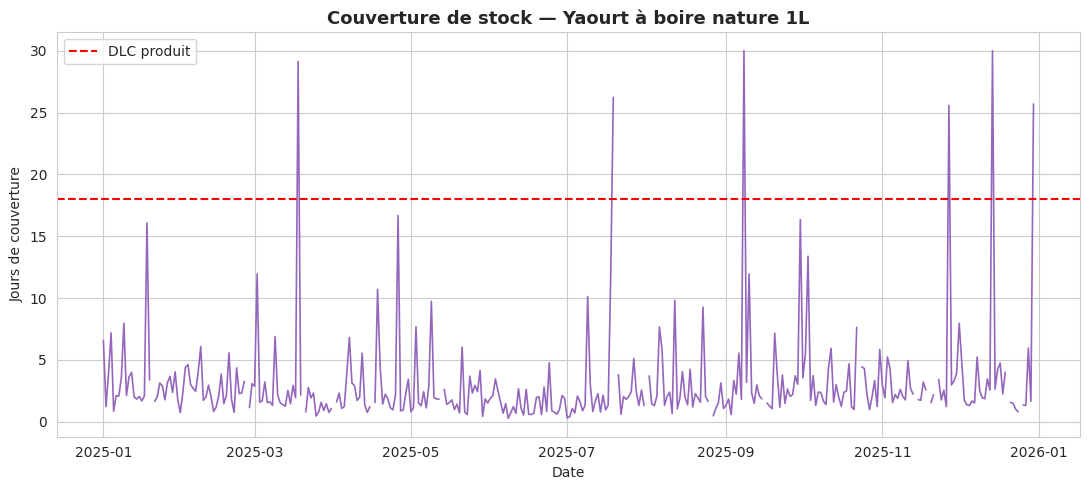

In [12]:
df['couverture_jours'] = (df['stock_fin_journee'] / df['demande'].replace(0, np.nan)).clip(upper=30)

sku_exemple = df_sku.iloc[0]['sku']
df_exemple = df[df['sku'] == sku_exemple].copy()

fig, ax = plt.subplots()
ax.plot(df_exemple['date'], df_exemple['couverture_jours'], color='#9467bd', linewidth=1.2)
ax.axhline(y=df_exemple['dlc_jours'].iloc[0], color='red', linestyle='--', label='DLC produit')
ax.set_title(f"Couverture de stock — {df_exemple['produit'].iloc[0]}")
ax.set_xlabel("Date")
ax.set_ylabel("Jours de couverture")
ax.legend()
plt.tight_layout()
plt.show()


Chaque dépassement de la ligne rouge (DLC) signale un risque de perte
imminent : le stock disponible représente plus de jours de vente que la durée
de vie du produit lui-même — une partie finira nécessairement à la poubelle.
C'est exactement ce type de signal que le **score d'alerte** développé dans le
notebook de détection d'anomalies devra capter automatiquement, en temps réel
plutôt qu'a posteriori.

## 7. Synthèse de l'analyse exploratoire

**Constats principaux :**

1. La demande présente une saisonnalité marquée (Ramadan, été, fêtes) qu'un
   modèle de prévision devra impérativement intégrer
2. Les desserts lactés (DLC la plus courte) concentrent la majorité des pertes —
   confirmant que la durée de vie du produit est le facteur de risque dominant
3. La classification ABC/XYZ met en évidence 2 à 3 références prioritaires
   (fort volume + forte variabilité) — cibles naturelles du futur modèle
   prédictif
4. Le taux de rupture global reste maîtrisé (~2-3%) mais certaines références
   présentent des pics de rupture corrélés aux périodes de forte demande

**Prochaine étape** : construction d'un modèle de prévision de la demande à
court terme (notebook `02_demand_forecasting_prophet.ipynb`) pour anticiper ces
pics et ajuster dynamiquement les niveaux de stock de sécurité — en priorité
sur les références identifiées comme les plus critiques dans la matrice
ABC/XYZ ci-dessus.